## Exploring the Met Office Global and UK Forecast Datasets

The [UK Met Office](https://www.metoffice.gov.uk/) produces two forecast datasets that are available in near-real-time in the [Microsoft Planetary Computer Data Catalog](https://planetarycomputer.microsoft.com/catalog). One for the entire globe and one that covers just the United Kingdom at a higher resolution.

The datasets are organized into 8 STAC collections that are designed to facilitate multidimensional analysis of the underlying assets:

- Global
  - [Height levels collection Met Office Global 10km deterministic weather forecast](https://planetarycomputer.microsoft.com/dataset/met-office-global-deterministic-height)
  - [Pressure levels collection Met Office Global 10km deterministic weather forecast](https://planetarycomputer.microsoft.com/dataset/met-office-global-deterministic-pressure)
  - [Whole Atmosphere collection Met Office Global 10km deterministic weather forecast](https://planetarycomputer.microsoft.com/dataset/met-office-global-deterministic-whole-atmosphere)
  - [Near-surface level collection Met Office global deterministic 10km forecast](https://planetarycomputer.microsoft.com/dataset/met-office-global-deterministic-near-surface)
  
- UK
  - [Height levels collection Met Office UKV 2km deterministic forecast](https://planetarycomputer.microsoft.com/dataset/met-office-uk-deterministic-height)
  - [Pressure levels collection Met Office UKV 2km deterministic forecast](https://planetarycomputer.microsoft.com/dataset/met-office-uk-deterministic-pressure)
  - [Whole Atmosphere collection Met Office UKV 2km deterministic forecast](https://planetarycomputer.microsoft.com/dataset/met-office-uk-deterministic-whole-atmosphere)
  - [Near-surface level collection Met Office UKV 2km deterministic forecast](https://planetarycomputer.microsoft.com/dataset/met-office-uk-deterministic-near-surface)
  
In this tutorial you will learn how to use targeted filters to query the Planetary Computer's Data Catalog so that you can analyze these rich datasets using `xarray`.

We will use [obspec-utils](https://obspec-utils.readthedocs.io/en/latest/) to open the NetCDF files over the network. obspec-utils is a new library based on [obstore](https://developmentseed.org/obstore/latest/) that provides convenient and efficient mechanisms for connecting xarray to files in object storage.

In [7]:
%pip install obspec-utils

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 13.1 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
from urllib.parse import urlparse
from pathlib import PurePosixPath

import matplotlib.pyplot as plt
import xarray as xr
from pystac_client import Client
from obstore.store import AzureStore
from obstore.auth.planetary_computer import PlanetaryComputerCredentialProvider
from obspec_utils.readers import BlockStoreReader


catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

### Global Height

The Global Height Levels collection contains forecasts of cloud volume at various height levels in the atmosphere. We can get the STAC items for the entire 89 time step forecast that was generated at 12:00 UTC on January 29, 2026 with the following STAC query. Each item's `datetime` property corresponds to the forecast time while `forecast:reference_datetime` refers to the time at which the forecast was generated.

In [2]:
search = catalog.search(
    collections="met-office-global-deterministic-height",
    filter_lang="cql2-json",
    filter={
        "op": "=",
        "args": [
            {"property": "forecast:reference_datetime"},
            "2026-01-29T12:00:00Z",
        ],
    },
    sortby="datetime",
)

items = search.item_collection()

print(f"found {len(items)} items")

items[0]

found 89 items


id: 20260129T1200Z-20260129T1200Z
"bbox: [-180.0, -90, 180, 90]"
datetime: 2026-01-29T12:00:00Z
"proj:wkt2: GEOGCS[""unknown"",DATUM[""unnamed"",SPHEROID[""Sphere"",6371229,0]],PRIMEM[""Greenwich"",0],UNIT[""degree"",0.0174532925199433,AUTHORITY[""EPSG"",""9122""]],AXIS[""Latitude"",NORTH],AXIS[""Longitude"",EAST]]"
forecast:horizon: PT0000H00M
forecast:reference_datetime: 2026-01-29T12:00:00Z
met_office_deterministic:model: global
met_office_deterministic:theme: height
https://stac-extensions.github.io/forecast/v0.2.0/schema.json
https://stac-extensions.github.io/projection/v1.1.0/schema.json
href: https://ukmoeuwest.blob.core.windows.net/deterministic/global/height/20260129T1200Z/20260129T1200Z-PT0000H00M-cloud_amount_on_height_levels.nc


In [3]:
asset_keys = list(items[0].assets.keys())
print("these items contain the following assets:", ", ".join(asset_keys))

these items contain the following assets: cloud_amount_on_height_levels


To access the assets over HTTP we can set up an `AzureStore` object store from `obstore` with the `PlanetaryComputerCredentialProvider` that will handle the url signing for us. This approach is very convenient because it will request the signing credentials when needed and refresh those credentials before the expire.

Azure uses the account, container, and a path prefix to determine the credential signing url for an asset so we need to split up the asset hrefs for this purpose.

In [20]:
parsed = urlparse(items[0].assets["cloud_amount_on_height_levels"].href)
first_dir = PurePosixPath(parsed.path).parts[1]

prefix = f"{parsed.scheme}://{parsed.netloc}/{first_dir}/"

asset_paths = [
    "/".join(PurePosixPath(urlparse(asset.href).path).parts[2:])
    for item in items
    if (asset := item.assets.get("cloud_amount_on_height_levels"))
]

print(prefix)
print(asset_paths[0])

https://ukmoeuwest.blob.core.windows.net/deterministic/
global/height/20260129T1200Z/20260129T1200Z-PT0000H00M-cloud_amount_on_height_levels.nc


Now we can construct an `AzureStore` with the PC credential provider and the `BlockStoreReader` to access the files over the network with some intelligent cach behavior that will improve read performance.

In [22]:
store = AzureStore(credential_provider=PlanetaryComputerCredentialProvider(prefix))

readers = [BlockStoreReader(store, path) for path in asset_paths]

Now we can lazily load all 89 of the forecast time steps into an xarray Dataset with `xarray.open_mfdataset`. xarray will intelligently concatenate the arrays along the relevant dimensions but we do need to specify the chunking scheme in order to structure the data for efficient subsetting. The native chunk size of these NetCDF files is (128, 128) along the latitude and longitude dimension which results in a very small chunk size. Increasing that to (256, 256) will reduce the number of requests that we need to make for any spatial subset read operations.

In [10]:
ds = xr.open_mfdataset(
    readers,
    engine="h5netcdf",
    chunks={"time": 1, "height": 1, "latitude": 256, "longitude": 256},
    decode_times=True,
    decode_timedelta=True,
    concat_dim="time",
    combine="nested",
    parallel=True,
)

ds

<xarray.Dataset>
Dimensions:                                    (time: 89, height: 33,
                                                latitude: 1920,
                                                longitude: 2560, bnds: 2)
Coordinates:
  * height                                     (height) float32 5.0 ... 6e+03
  * latitude                                   (latitude) float32 -89.95 ... ...
  * longitude                                  (longitude) float32 -179.9 ......
    forecast_period                            (time) timedelta64[ns] 00:00:0...
    forecast_reference_time                    datetime64[ns] 2026-01-29T12:0...
  * time                                       (time) datetime64[ns] 2026-01-...
Dimensions without coordinates: bnds
Data variables:
    cloud_volume_fraction_in_atmosphere_layer  (time, height, latitude, longitude) float32 dask.array<chunksize=(1, 1, 256, 256), meta=np.ndarray>
    latitude_longitude                         (time) int32 -2147483647 ... -...
    latitude_bnds                              (time, latitude, bnds) float32 dask.array<chunksize=(1, 256, 2), meta=np.ndarray>
    longitude_bnds                             (time, longitude, bnds) float32 dask.array<chunksize=(1, 256, 2), meta=np.ndarray>
Attributes:
    history:                      2026-01-29T15:13:50Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT168H
    mosg__grid_domain:            global
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    gl_det
    source:                       Met Office Unified Model
    title:                        Global Model Forecast on Global 10 km Stand...
    um_version:                   13.8
    Conventions:                  CF-1.7, UKMO-1.0

To get the forecast values for a location and 10 of the height levels we can use the `sel` and `isel` methods. When we read the data from the `local_forecast` subset xarray will perform targeted network requests for just the data included in our desired range of height levels and for the chunks that overlap the specified coordinates.

In [16]:
local_forecast = (
    ds["cloud_volume_fraction_in_atmosphere_layer"]
    .sel(latitude=46.8, longitude=-92.1, method="nearest")
    .isel(height=slice(0, 10))
)

local_forecast

<xarray.DataArray 'cloud_volume_fraction_in_atmosphere_layer' (time: 89,
                                                               height: 10)>
dask.array<getitem, shape=(89, 10), dtype=float32, chunksize=(1, 1), chunktype=numpy.ndarray>
Coordinates:
  * height                   (height) float32 5.0 10.0 20.0 ... 200.0 250.0
    latitude                 float32 46.83
    longitude                float32 -92.04
    forecast_period          (time) timedelta64[ns] 00:00:00 ... 7 days 00:00:00
    forecast_reference_time  datetime64[ns] 2026-01-29T12:00:00
  * time                     (time) datetime64[ns] 2026-01-29T12:00:00 ... 20...
Attributes:
    least_significant_digit:  2
    long_name:                cloud_volume_fraction_in_atmosphere_layer
    units:                    1
    grid_mapping:             latitude_longitude

In [ ]:
local_forecast.load()

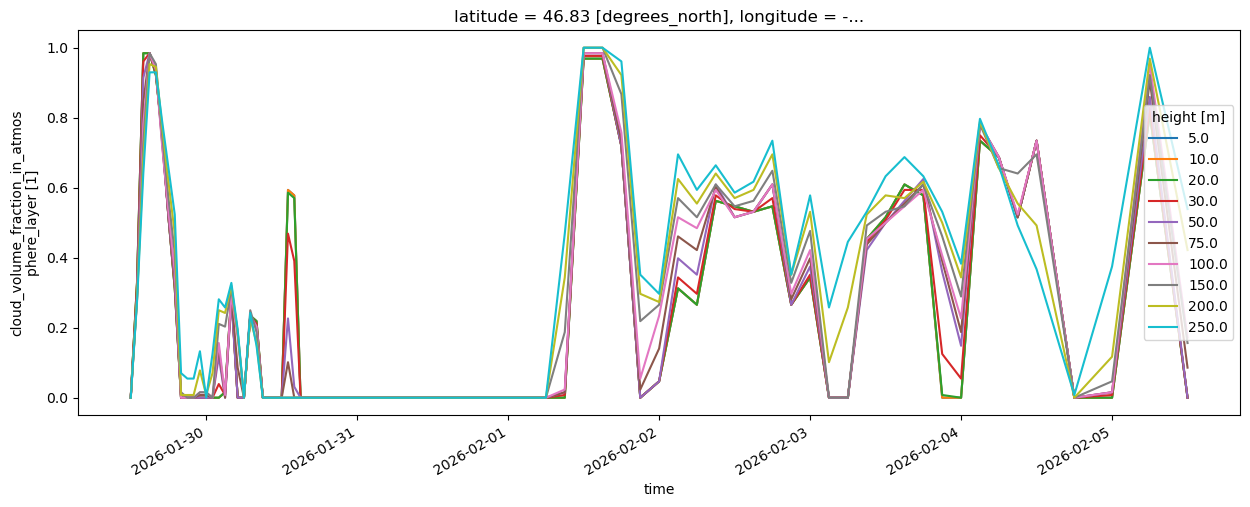

In [25]:
plt.figure(figsize=(15, 5))
_ = local_forecast.plot.line(x="time")
plt.show()

We can also select specific slices of the entire global dataset and plot them on a map. This example plucks the 100 m height layer and the first 6 time steps from the forecast.

In [28]:
global_view = (
    ds["cloud_volume_fraction_in_atmosphere_layer"]
    .sel(height=100)
    .isel(time=slice(0, 6))
)
global_view

<xarray.DataArray 'cloud_volume_fraction_in_atmosphere_layer' (time: 6,
                                                               latitude: 1920,
                                                               longitude: 2560)>
dask.array<getitem, shape=(6, 1920, 2560), dtype=float32, chunksize=(1, 256, 256), chunktype=numpy.ndarray>
Coordinates:
    height                   float32 100.0
  * latitude                 (latitude) float32 -89.95 -89.86 ... 89.86 89.95
  * longitude                (longitude) float32 -179.9 -179.8 ... 179.8 179.9
    forecast_period          (time) timedelta64[ns] 00:00:00 ... 05:00:00
    forecast_reference_time  datetime64[ns] 2026-01-29T12:00:00
  * time                     (time) datetime64[ns] 2026-01-29T12:00:00 ... 20...
Attributes:
    least_significant_digit:  2
    long_name:                cloud_volume_fraction_in_atmosphere_layer
    units:                    1
    grid_mapping:             latitude_longitude

<Figure size 1600x800 with 0 Axes>

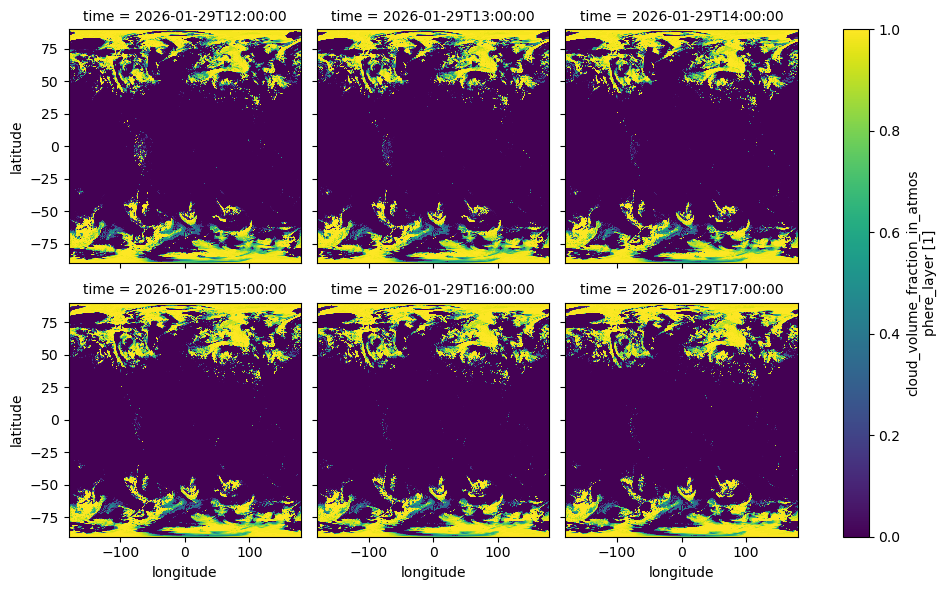

In [30]:
plt.figure(figsize=(16, 8))
_ = global_view.plot.imshow(cmap="viridis", col="time", col_wrap=3)
plt.show()